# The control group is a fitted object, and its failures do not show up in the plot you publish

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/synthetic-control/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/synthetic-control/demo.ipynb)

**Day 169 - `synthetic-control` - Data Science Cookbook**

One market got the intervention. There is no control group and there is never going to be
one, so synthetic control builds it: a weighted average of the other markets, with the
weights chosen to track the treated market before the intervention. The weights are
non-negative and sum to one, which makes the result a convex combination - a market that
could plausibly have existed - rather than a regression that extrapolates.

It is a genuinely good estimator, and section 1 measures it beating every alternative. The
rest of this notebook is about the thing that makes it dangerous in practice: **the evidence
it presents for itself is the pre-period fit, and the pre-period fit was chosen to look
good.** Five of the six failures below leave that plot untouched or improved.

| # | What it shows |
|---|---|
| 1 | The estimator working: 2-3x better than the closest donor, the donor average, or diff-in-diff |
| 2 | The p-value has a floor of 1/(donors+1), and at 10 donors a 0.05 result is unreachable at any effect size |
| 3 | Growing the donor pool improves the published pre-period fit 3x and the accuracy not at all |
| 4 | Outside the convex hull the bias runs 0.1-0.7 of the shortfall, and one honest diagnostic sees it |
| 5 | A spillover into one donor attenuates the estimate by exactly its weight, with a perfect pre-period fit |
| 6 | Which lever to pull: history buys accuracy, donors buy hull coverage, and they are not substitutes |

Everything runs on generated panels with a known true effect, so every claim below is checked
against a number the notebook already knows.

## The engine

The whole estimator is one constrained least-squares problem. Solving it as a non-negative
least squares with the sum-to-one constraint appended as a heavily weighted row is exact and
takes about 30 microseconds, which is what makes the placebo permutations below cheap enough
to run thousands of times.

In [1]:
from __future__ import annotations

from typing import Dict, List, Optional

import numpy as np
from scipy.optimize import nnls


def solve_simplex_ls(X: np.ndarray, y: np.ndarray, penalty: float = 1e6) -> np.ndarray:
    """argmin_w ||Xw - y||^2 subject to w >= 0, sum(w) = 1."""
    m = penalty * (float(np.abs(X).max()) or 1.0)
    x_aug = np.vstack([X, np.full((1, X.shape[1]), m)])
    y_aug = np.concatenate([y, [m]])
    w, _ = nnls(x_aug, y_aug)
    return w


def fit(Y: np.ndarray, treated: int, t_pre: int, constrained: bool = True):
    """Y is (units, periods).  Returns weights and the gap in every period."""
    donors = [i for i in range(Y.shape[0]) if i != treated]
    X, y = Y[donors, :t_pre].T, Y[treated, :t_pre]
    w = solve_simplex_ls(X, y) if constrained else np.linalg.lstsq(X, y, rcond=None)[0]
    return w, Y[treated] - w @ Y[donors, :]


def att(gaps: np.ndarray, t_pre: int) -> float:
    return float(gaps[t_pre:].mean())


def pre_rmspe(gaps: np.ndarray, t_pre: int) -> float:
    return float(np.sqrt((gaps[:t_pre] ** 2).mean()))


def make_panel(rng, n_donors=20, t_pre=30, t_post=12, k=3, noise=1.0, effect=0.0,
               mix_alpha=0.3, hull_shift=0.0, contaminated=None, anticipation=0,
               anticipation_share=1.0):
    """Y_it = lambda_i . F_t + eps.  The treated unit's loadings are a lopsided convex
    combination of the donors', so a perfect synthetic control exists."""
    T = t_pre + t_post
    F = np.cumsum(rng.normal(0, 1, (k, T)), axis=1) + rng.normal(0, 1, (k, T))
    donor_load = rng.uniform(0.2, 1.8, (n_donors, k))
    treated_load = rng.dirichlet(np.ones(n_donors) * mix_alpha) @ donor_load
    Y = np.vstack([treated_load, donor_load]) @ F + rng.normal(0, noise, (n_donors + 1, T))
    Y[0] += hull_shift
    if anticipation:
        Y[0, t_pre - anticipation:t_pre] += np.linspace(0, effect * anticipation_share, anticipation + 1)[1:]
    Y[0, t_pre:] += effect
    for j, g in (contaminated or {}).items():
        Y[j + 1, t_pre:] += g * effect
    return Y


EFFECT = 5.0
rng = np.random.default_rng(1000)
Y = make_panel(rng, effect=EFFECT)
w, gaps = fit(Y, 0, 30)

print(f"weights sum to {w.sum():.6f}, {(w > 1e-4).sum()} of 20 donors carry any weight")
print(f"true effect {EFFECT:.2f}   estimate {att(gaps, 30):.3f}   pre-period RMSPE {pre_rmspe(gaps, 30):.3f}")

weights sum to 1.000000, 10 of 20 donors carry any weight
true effect 5.00   estimate 4.957   pre-period RMSPE 0.601


## 1. It works, and the alternatives do not

The three things people actually reach for when there is no control group are the single
market that looks most similar, the average of all the others, and a difference-in-differences
against that average. Over 400 generated panels with a true effect of 5.0:

In [2]:
def naive(Y, t_pre):
    donors = [i for i in range(Y.shape[0]) if i != 0]
    y_t, d = Y[0], Y[donors]
    errs = ((d[:, :t_pre] - y_t[:t_pre]) ** 2).mean(axis=1)
    best, avg = d[int(errs.argmin())], d.mean(axis=0)
    return {
        "closest donor": float((y_t[t_pre:] - best[t_pre:]).mean() - (y_t[:t_pre] - best[:t_pre]).mean()),
        "donor average": float((y_t[t_pre:] - avg[t_pre:]).mean()),
        "diff-in-diff": float((y_t[t_pre:].mean() - y_t[:t_pre].mean()) - (avg[t_pre:].mean() - avg[:t_pre].mean())),
    }


acc = {"synthetic": []}
for s in range(400):
    Yi = make_panel(np.random.default_rng(1000 + s), effect=EFFECT)
    acc["synthetic"].append(att(fit(Yi, 0, 30)[1], 30))
    for name, v in naive(Yi, 30).items():
        acc.setdefault(name, []).append(v)


def rmse(v):
    return float(np.sqrt(((np.array(v) - EFFECT) ** 2).mean()))


base = rmse(acc["synthetic"])
print(f"{'estimator':<16}{'mean':>8}{'bias':>8}{'rmse':>8}{'x synthetic':>13}")
for name in ("synthetic", "diff-in-diff", "closest donor", "donor average"):
    v = np.array(acc[name])
    print(f"{name:<16}{v.mean():>8.3f}{v.mean() - EFFECT:>8.3f}{rmse(v):>8.3f}{rmse(v) / base:>13.2f}")

estimator           mean    bias    rmse  x synthetic
synthetic          4.964  -0.036   0.567         1.00
diff-in-diff       5.085   0.085   1.270         2.24
closest donor      4.800  -0.200   1.547         2.73
donor average      5.162   0.162   1.876         3.31


## 2. The smallest p-value you can get is decided before you collect anything

There is one treated unit, so there is no sampling distribution to lean on. Inference is a
permutation: refit the estimator with each donor playing the treated unit, and rank the real
one. With N units there are exactly N possible ranks, so the smallest reachable p-value is
1/N = 1/(donors + 1).

This is arithmetic on the donor count. No effect size moves it. A study of twelve US states
cannot report a 5% result no matter what the intervention did.

In [3]:
def placebo_p(Y, t_pre, statistic="ratio"):
    stats = []
    for i in range(Y.shape[0]):
        _, g = fit(Y, i, t_pre)
        pre = (g[:t_pre] ** 2).mean()
        stats.append((g[t_pre:] ** 2).mean() / pre if statistic == "ratio" else abs(g[t_pre:].mean()))
    stats = np.array(stats)
    return float((stats >= stats[0]).sum() / len(stats))


print(f"{'donors':>8}{'floor':>10}{'0.05?':>8}   power of the placebo test at 0.05")
for j in (10, 20, 40):
    floor = 1 / (j + 1)
    rejects = {}
    for eff in (2.0, 5.0, 10.0):
        ps = [placebo_p(make_panel(np.random.default_rng(20000 + s), n_donors=j, effect=eff), 30) for s in range(150)]
        rejects[eff] = float(np.mean(np.array(ps) <= 0.05))
    detail = "  ".join(f"tau={e:.0f}: {r:.2f}" for e, r in rejects.items())
    print(f"{j:>8}{floor:>10.4f}{'yes' if floor <= 0.05 else 'NO':>8}   {detail}")

  donors     floor   0.05?   power of the placebo test at 0.05
      10    0.0909      NO   tau=2: 0.00  tau=5: 0.00  tau=10: 0.00
      20    0.0476     yes   tau=2: 0.71  tau=5: 0.99  tau=10: 1.00
      40    0.0244     yes   tau=2: 0.76  tau=5: 1.00  tau=10: 1.00


The 10-donor row is worth staring at. Its power against an effect twice the size that 40
donors detects with certainty is **0.00** - not low, zero. The test has no outcome that
rejects, because the smallest number it can print is 0.0909.

That is a design decision, and it is available before the study starts.

## 3. The pre-period fit is the credential, and it is not evidence

Every synthetic control paper opens with two lines lying on top of each other before the
intervention. It is offered as proof the counterfactual is trustworthy. But the weights were
*chosen* to make those lines coincide, so the fit measures how much freedom the optimiser had -
and freedom grows with the donor pool.

Below, the pre-period is held at 10 and the pool is grown from 5 donors to 80.

In [4]:
print(f"{'donors':>8}{'pre-RMSPE':>12}{'error in the estimate':>24}")
s3 = []
for j in (5, 10, 20, 40, 80):
    pre, atts = [], []
    for s in range(300):
        Yi = make_panel(np.random.default_rng(30000 + s), n_donors=j, t_pre=10, effect=EFFECT)
        _, g = fit(Yi, 0, 10)
        pre.append(pre_rmspe(g, 10))
        atts.append(att(g, 10))
    s3.append((j, float(np.mean(pre)), rmse(atts)))
    print(f"{j:>8}{np.mean(pre):>12.3f}{rmse(atts):>24.3f}")

print(f"\npre-period fit improved {s3[0][1] / s3[-1][1]:.1f}x;"
      f" accuracy changed by {(s3[-1][2] / s3[0][2] - 1) * 100:+.1f}%")

  donors   pre-RMSPE   error in the estimate
       5       0.979                   0.901
      10       0.775                   0.894
      20       0.575                   0.843
      40       0.440                   0.822
      80       0.326                   0.877

pre-period fit improved 3.0x; accuracy changed by -2.6%


## 4. The convex hull is a wall, and there is an honest way to measure it

Non-negative weights summing to one mean the synthetic unit can never be above the highest
donor or below the lowest, in any period. If the treated market sits above its whole pool,
no weighting reaches it.

The intuitive guess is that a shortfall of `h` produces a bias of `h`. It does not: the
optimiser buys part of it back by tilting toward the highest-level donors and paying in
factor fit. What *is* available is the **hull excess** - how far outside the donor range the
treated path lies - which needs no counterfactual and no knowledge of the true effect.

In [5]:
def hull_excess(Y, t_pre):
    lo, hi = Y[1:].min(axis=0), Y[1:].max(axis=0)
    ex = np.maximum(Y[0] - hi, 0.0) + np.minimum(Y[0] - lo, 0.0)
    return float(ex[t_pre:].mean())


print(f"{'shift h':>9}{'estimate':>11}{'bias':>9}{'bias/h':>9}{'hull excess':>14}{'pre-RMSPE':>12}")
s4 = []
for h in (0.0, 1.0, 2.0, 5.0, 10.0, 20.0):
    atts, pres, exc = [], [], []
    for s in range(250):
        Yi = make_panel(np.random.default_rng(40000 + s), effect=EFFECT, hull_shift=h)
        _, g = fit(Yi, 0, 30)
        atts.append(att(g, 30)); pres.append(pre_rmspe(g, 30)); exc.append(hull_excess(Yi, 30))
    b = float(np.mean(atts)) - EFFECT
    s4.append((h, float(np.mean(atts)), b, float(np.mean(exc))))
    print(f"{h:>9.1f}{np.mean(atts):>11.3f}{b:>9.3f}{(b / h if h else 0):>9.3f}"
          f"{np.mean(exc):>14.3f}{np.mean(pres):>12.3f}")

  shift h   estimate     bias   bias/h   hull excess   pre-RMSPE
      0.0      5.039    0.039    0.000         0.360       0.858
      1.0      5.111    0.111    0.111         0.640       0.980
      2.0      5.205    0.205    0.103         1.025       1.287
      5.0      6.022    1.022    0.204         2.792       2.871
     10.0      9.440    4.440    0.444         7.024       6.784
     20.0     19.052   14.052    0.703        16.846      16.213


Two things to take from that table. The bias runs at roughly 0.1 to 0.7 of the shortfall and
the fraction *grows* with it, so there is no single multiplier to correct by. And unlike every
other failure in this notebook, this one is visible - both in the pre-period RMSPE and, more
usefully, in a hull excess that nobody reports.

## 5. A spillover into one donor, and a perfect pre-period fit

The donor pool is assumed untouched. When a neighbouring market picks up share `gamma` of
the effect and carries weight `w` in the fit, the synthetic control rises with the real one
and that share is subtracted from the answer:

$$\hat\tau = \tau \left(1 - \sum_j w_j \gamma_j\right)$$

The weights on the right are the ones the optimiser happened to choose, so this is not a
correction anyone can apply in advance - it is a description of the damage. And because the
contamination is entirely post-period, **the pre-period fit is bit-for-bit unchanged.**

In [6]:
print(f"{'gamma':>7}{'donors hit':>12}{'estimate':>11}{'measured':>11}{'predicted':>11}{'pre-RMSPE':>12}")
for gamma, n_hit in ((0.0, 1), (0.5, 1), (1.0, 1), (1.0, 3), (0.5, 5)):
    ratios, preds, pres = [], [], []
    for s in range(250):
        base_Y = make_panel(np.random.default_rng(70000 + s), effect=EFFECT)
        w0, _ = fit(base_Y, 0, 30)
        hit = [int(i) for i in np.argsort(w0)[::-1][:n_hit]]
        Yi = make_panel(np.random.default_rng(70000 + s), effect=EFFECT,
                        contaminated={i: gamma for i in hit})
        wi, g = fit(Yi, 0, 30)
        ratios.append(att(g, 30) / EFFECT)
        preds.append(1.0 - sum(wi[i] * gamma for i in hit))
        pres.append(pre_rmspe(g, 30))
    print(f"{gamma:>7.1f}{n_hit:>12}{np.mean(ratios) * EFFECT:>11.3f}{np.mean(ratios):>11.4f}"
          f"{np.mean(preds):>11.4f}{np.mean(pres):>12.4f}")

  gamma  donors hit   estimate   measured  predicted   pre-RMSPE
    0.0           1      5.022     1.0043     1.0000      0.8370
    0.5           1      4.317     0.8634     0.8591      0.8370
    1.0           1      3.612     0.7225     0.7181      0.8370
    1.0           3      1.794     0.3589     0.3546      0.8370
    0.5           5      2.870     0.5741     0.5698      0.8370


The measured and predicted columns differ by the same constant in every row - read it off the
`gamma = 0.0` row, where there is no contamination at all. That constant is the estimator's
own clean bias, and it does not budge while the contamination destroys two thirds of the
effect. The attenuation is fully explained by the weights the optimiser chose.

Read the last column: it is the same number in every row. Two thirds of the effect has been
erased and the diagnostic is not merely uninformative, it is **perfect**.

## 6. Which lever: history or donors?

Both are things a researcher can go and get. They are not substitutes, and which one you
need depends on which failure you have - which is exactly what the published plot cannot
tell you.

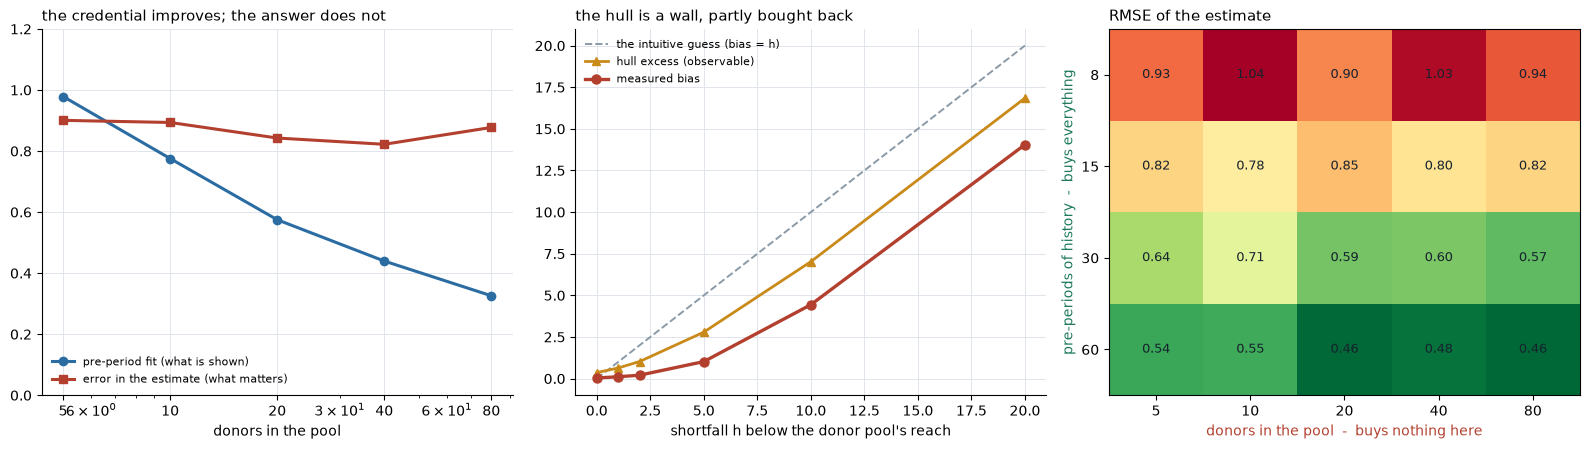

16x the history: 0.926 -> 0.542   (+41%)
16x the donors:  0.926 -> 0.943   (-2%)


In [7]:
import matplotlib.pyplot as plt

INK, BAD, COOL, GOOD, GRID = "#16222e", "#b3402f", "#2b6ca3", "#1f7a5c", "#dfe5ea"

pres_grid, donors_grid = [8, 15, 30, 60], [5, 10, 20, 40, 80]
M = np.zeros((len(pres_grid), len(donors_grid)))
for i, tp in enumerate(pres_grid):
    for k, j in enumerate(donors_grid):
        M[i, k] = rmse([att(fit(make_panel(np.random.default_rng(90000 + s), n_donors=j,
                                           t_pre=tp, effect=EFFECT), 0, tp)[1], tp) for s in range(200)])

fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(16, 4.6))
fig.patch.set_facecolor("white")

j3, pre3, err3 = [r[0] for r in s3], [r[1] for r in s3], [r[2] for r in s3]
axA.plot(j3, pre3, "o-", color=COOL, lw=2.2, ms=6, label="pre-period fit (what is shown)")
axA.plot(j3, err3, "s-", color=BAD, lw=2.2, ms=6, label="error in the estimate (what matters)")
axA.set_xscale("log"); axA.set_xticks(j3); axA.set_xticklabels([str(x) for x in j3])
axA.set_xlabel("donors in the pool"); axA.set_ylim(0, 1.2)
axA.set_title("the credential improves; the answer does not", fontsize=11, loc="left")
axA.legend(fontsize=8, frameon=False, loc="lower left")

h4, bias4, exc4 = [r[0] for r in s4], [r[2] for r in s4], [r[3] for r in s4]
axB.plot(h4, h4, color="#8b9aa7", lw=1.4, ls="--", label="the intuitive guess (bias = h)")
axB.plot(h4, exc4, "^-", color="#c98a1a", lw=2.0, ms=6, label="hull excess (observable)")
axB.plot(h4, bias4, "o-", color=BAD, lw=2.4, ms=6.5, label="measured bias")
axB.set_xlabel("shortfall h below the donor pool's reach")
axB.set_title("the hull is a wall, partly bought back", fontsize=11, loc="left")
axB.legend(fontsize=8, frameon=False, loc="upper left")

im = axC.imshow(M, cmap="RdYlGn_r", aspect="auto")
for i in range(len(pres_grid)):
    for k in range(len(donors_grid)):
        axC.text(k, i, f"{M[i, k]:.2f}", ha="center", va="center", fontsize=9, color=INK)
axC.set_xticks(range(len(donors_grid))); axC.set_xticklabels(donors_grid)
axC.set_yticks(range(len(pres_grid))); axC.set_yticklabels(pres_grid)
axC.set_xlabel("donors in the pool  -  buys nothing here", color=BAD)
axC.set_ylabel("pre-periods of history  -  buys everything", color=GOOD)
axC.set_title("RMSE of the estimate", fontsize=11, loc="left")

for ax in (axA, axB):
    ax.grid(True, color=GRID, lw=0.7); ax.set_axisbelow(True)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig("synth_notebook_figure.png", dpi=150, facecolor="white")
plt.show()

print(f"16x the history: {M[0][0]:.3f} -> {M[-1][0]:.3f}   ({(1 - M[-1][0] / M[0][0]) * 100:+.0f}%)")
print(f"16x the donors:  {M[0][0]:.3f} -> {M[0][-1]:.3f}   ({(1 - M[0][-1] / M[0][0]) * 100:+.0f}%)")

## What this leaves you with

| Failure | What it does to the estimate | What the pre-period plot does |
|---|---|---|
| A bigger donor pool (not a failure - a lever) | nothing measurable | **improves 3x**, so the paper looks stronger for free |
| Too few donors for inference | nothing; but makes p <= 0.05 unreachable at any effect size | silent |
| Outside the convex hull | bias of 0.1-0.7 x the shortfall | **worsens** - the one honest signal |
| Spillover into a donor | attenuates by exactly the contaminated weight | **unchanged, to four decimals** |
| Anticipation | biases downward, opposite sign to the rest | worsens, but only when the leak is loud |
| Unconstrained weights instead of the simplex | 1.8x worse (measured in `evidence.py`) | improves to a *perfect* fit |

The last row is the whole problem in miniature. Dropping the constraint that makes synthetic
control what it is produces a pre-period fit that passes through every point exactly - the
most convincing version of the picture in any paper - and the worst estimator measured here.

Three things worth carrying:

1. **Count the donors before you start.** The p-value floor is 1/(J+1) and it is not
   negotiable later.
2. **Report the hull excess.** It costs two lines, it needs no counterfactual, and it is
   the only diagnostic here that sees a failure the pre-period plot does not.
3. **The pre-period fit is not a test.** It is the objective function. A good one means the
   optimiser succeeded at its own task, which is a different question from whether the
   counterfactual is right.

## Try your own

In [8]:
# Change these and re-run.  Some things to try:
#   hull_shift=8       - the treated market sits above its whole pool
#   contaminated={0:1} - the highest-weighted donor got treated too
#   anticipation=6     - the market moved six periods before the official date
#   n_donors=8         - watch the p-value floor make 0.05 unreachable

# One panel is one draw.  Section 1 measured an RMSE of ~0.57 on clean panels, so an error
# of half a point here is ordinary noise and not a sign anything is broken - the failures in
# this notebook are the ones that survive averaging over hundreds of panels.

TRUE_EFFECT = 5.0
Y_yours = make_panel(
    np.random.default_rng(7),
    n_donors=20,
    t_pre=30,
    effect=TRUE_EFFECT,
    hull_shift=0.0,
    contaminated=None,
    anticipation=0,
)

w_yours, g_yours = fit(Y_yours, 0, 30)
print(f"true effect      {TRUE_EFFECT:.3f}")
print(f"estimate         {att(g_yours, 30):.3f}   ({att(g_yours, 30) - TRUE_EFFECT:+.3f})")
print(f"pre-period RMSPE {pre_rmspe(g_yours, 30):.3f}   <- the credential")
print(f"hull excess      {hull_excess(Y_yours, 30):.3f}   <- the diagnostic nobody reports")
print(f"placebo p        {placebo_p(Y_yours, 30):.3f}   (floor {1 / Y_yours.shape[0]:.3f})")

true effect      5.000
estimate         5.339   (+0.339)
pre-period RMSPE 0.857   <- the credential
hull excess      0.000   <- the diagnostic nobody reports
placebo p        0.048   (floor 0.048)


---

**Repo:** [phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) ·
Day 169 · `data-science-cookbook/synthetic-control`

This is the sixth build in the experiment-soundness run and the first that is not about a
randomised test at all. The others: [`peeking-cost`](../peeking-cost/) (when you looked),
[`srm-detector`](../srm-detector/) (who ended up in which arm),
[`cuped-variance`](../cuped-variance/) (needing fewer users),
[`diff-in-diff`](../diff-in-diff/) (when you could not randomise) and
[`interference-check`](../interference-check/) (when the units touch each other). Section 5
here is that last one at a different level - contamination between the treated unit and its
own control group rather than between two arms of one experiment.

**The full build:**
- `python evidence.py` - the nine-section measurement, ~12s
- `python -m pytest test_synth.py` - 22 assertions behind every number
- `streamlit run app.py` - pick a failure mode, watch the credential stay clean
- `python make_chart.py` - the six-panel figure

**Reading, for the results this build re-derives rather than cites:** Abadie & Gardeazabal
(2003) and Abadie, Diamond & Hainmueller (2010, 2015) on the estimator and the placebo test;
Ferman & Pinto (2021) on inference with imperfect pre-treatment fit; Abadie (2021) for the
convex-hull and donor-pool guidance.